# **NBA Aging Curve Solution Pipeline**

### **This notebook contains the project problem solution pipeline. The data stored in MongoDB in the data generating script will be loaded from the MongoDB database into a pandas DataFrame, and used to solve the project problem:**

Predicting how NBA player Box Plus Minus (BPM) changes as a function of age, position, and injury history in order to model career aging curves that inform future player progression or regression.

## **Pipeline Contents**

- Package Imports
- Logging
- Connecting to MongoDB
- Loading Data into DataFrame
- Feature Engineering
- Building Age Curve Model
- Analyzing Results
- Visualization of Results
- Conclusion

## **Imports**

The following packages are imported for use in the solution pipeline.

In [23]:
# Imports
import statsmodels.formula.api as smf
from dotenv import load_dotenv
import pandas as pd
import logging
import pymongo
import os

## **Logger Initialization**

This is the initialization of the logger used throughout the pipeline notebook.

In [24]:
# Initializing logger
logging.basicConfig(
    level = logging.INFO, 
    format = '%(asctime)s - %(levelname)s - %(message)s',  # Timestamp, level, and message format
    filename = 'pipeline.log'
)
logger = logging.getLogger(__name__)

## **Connecting to MongoDB**

This is the connection to the MongoDB database. Credentials are loaded in the the environment to maintain a secure database. The data is stored in the `players` collection of the `bref-data` database.

In [25]:
# Load MongoDB credentials from .env
MONGO_USERNAME = os.getenv("MONGO_USERNAME")
MONGO_PASSWORD = os.getenv("MONGO_PASSWORD")
MONGO_CLUSTER = os.getenv("MONGO_CLUSTER")
MONGO_APP_NAME = os.getenv("MONGO_APP_NAME")

# Connection string and client connection
conn = f"mongodb+srv://{MONGO_USERNAME}:{MONGO_PASSWORD}@{MONGO_CLUSTER}/?appName={MONGO_APP_NAME}"
client = pymongo.MongoClient(conn)

# Access the database and collection
db = client['bref-data']
collection = db['players']

# Show collection to verify
print(db.list_collection_names())
logger.info("Connected to MongoDB and accessed the 'players' collection")

['players']


## **Loading Data into DataFrame**

This is where the data from the MongoDB database is loaded into a Pandas DataFrame. The data is loaded such that each row represents a player-season (Ex. Steph Curry 2016).

In [26]:
# Get all documents from the collection
all_documents = collection.find({})
documents = list(all_documents)

# Use json_normalize to flatten the nested seasons array into a DataFrame
df = pd.json_normalize(
    documents,
    record_path = 'seasons',
    meta = ['_id', 'name']
)

# Reorder the columns so player identifiers are at the front
cols = ['_id', 'name'] + [col for col in df.columns if col not in ['_id', 'name']]
df = df[cols]

# Display the first few rows to verify
display(df.head(3))
logger.info("Data loaded into Pandas DataFrame")

,_id,name,season,age,team,games_played,games_started,games_missed,injury_flag,minutes_per_game,...,PER,TS_pct,USG_pct,AST_pct,TOV_pct,OREB_pct,DREB_pct,WS,BPM,VORP
0,tracy_mcgrady,Tracy McGrady,2003-04,24,ORL,67,67,15,False,39.9,...,25.3,0.526,33.2,28.3,9.1,3.9,13.3,8.4,6.4,5.7
1,tracy_mcgrady,Tracy McGrady,2004-05,25,HOU,78,78,4,False,40.8,...,22.9,0.526,31.2,28.6,9.5,2.7,14.8,12.0,6.7,6.9
2,tracy_mcgrady,Tracy McGrady,2005-06,26,HOU,47,47,35,False,37.1,...,21.9,0.494,35.0,28.8,9.4,3.1,17.2,4.1,5.4,3.3


Modeling on 7107 player-seasons
Across 1377 unique players
                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     BPM        
No. Observations:     7107        Method:                 REML       
No. Groups:           1377        Scale:                  1.8456     
Min. group size:      1           Log-Likelihood:         -13913.1265
Max. group size:      23          Converged:              Yes        
Mean group size:      5.2                                            
---------------------------------------------------------------------
                     Coef.   Std.Err.    z    P>|z|  [0.025   0.975] 
---------------------------------------------------------------------
Intercept           -151.195   16.990  -8.899 0.000 -184.494 -117.895
age                   18.926    2.467   7.673 0.000   14.092   23.761
age_sq                -0.900    0.133  -6.785 0.000   -1.160   -0.640
age_cu                 0.019    0.003   6.078 0

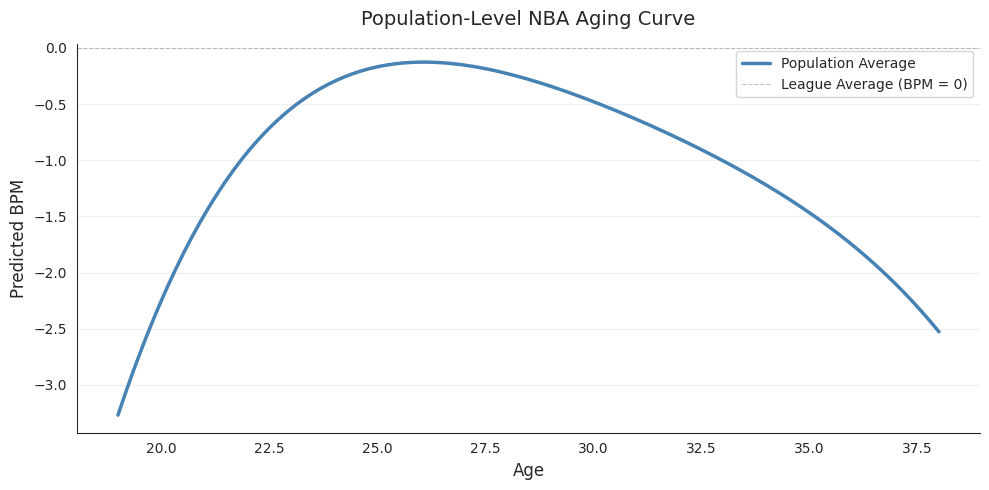

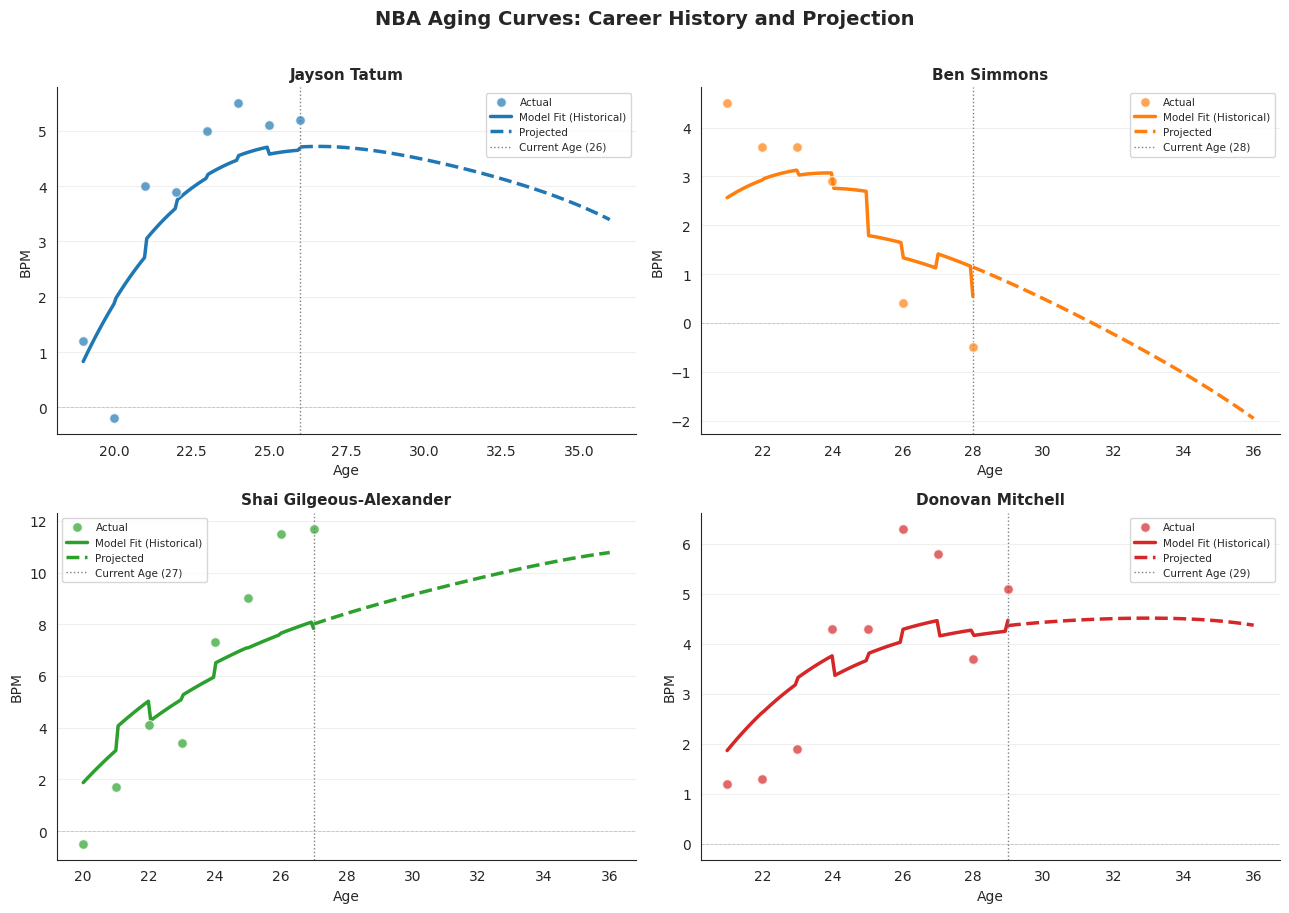

In [27]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Subset and filter data
df_model = df[(df["games_played"] >= 20) & (df["minutes_per_game"] >= 15)].copy()
df_model  = df_model.sort_values(["name", "season"]).reset_index(drop = True)

# Polynomial age features
df_model["age_sq"] = df_model["age"] ** 2
df_model["age_cu"] = df_model["age"] ** 3
df_model["age_4"]  = df_model["age"] ** 4


# Lagged injury flag
df_model["injured_last_season"] = (
    df_model
    .groupby("name")["injury_flag"]
    .shift(1)
    .fillna(False)
    .astype(int)
)

# Current season workload
df_model["minutes_per_game"] = df_model["minutes_per_game"].astype(float)

print(f"Modeling on {len(df_model)} player-seasons")
print(f"Across {df_model['name'].nunique()} unique players")


# Fit mixed effects model with random intercepts and slopes for age
model = smf.mixedlm(
    """BPM ~ age + age_sq + age_cu + age_4
           + minutes_per_game
           + injured_last_season
           + games_missed""",
    df_model,
    groups = df_model["name"],
    re_formula = "~age"
)
result = model.fit(method="lbfgs")
print(result.summary())

random_effects = result.random_effects

# Function to evaluate player-specific curves with optional load extrapolation
def player_curve(player_name, ages, df_model, result, random_effects,
                 use_projected_load = False):
    """
    Evaluate the model curve for a player at given ages.

    For historical ages: uses actual observed minutes and injury values.
    For projected ages: uses the player's recent average as a forward assumption,
                        with career_minutes accumulated forward each season.

    Parameters
    ----------
    player_name         : str
    ages                : np.ndarray — ages to evaluate at
    df_model            : DataFrame — full modeling data
    result              : fitted model
    random_effects      : dict of random effects per player
    use_projected_load  : if True, extrapolate load features for future ages
    """
    re          = random_effects[player_name]
    player_data = df_model[df_model["name"] == player_name].sort_values("age")
    current_age = player_data["age"].max()

    # Use recent 3-season average for forward load assumptions
    recent      = player_data.tail(3)
    avg_mpg     = recent["minutes_per_game"].mean()
    avg_missed  = recent["games_missed"].mean()

    predictions = []

    for age in ages:
        # For historical ages, use actual observed values
        actual_row = player_data[player_data["age"] == int(age)]
        if not actual_row.empty and not use_projected_load:
            mpg          = actual_row["minutes_per_game"].values[0]
            missed       = actual_row["games_missed"].values[0]
            inj_last     = actual_row["injured_last_season"].values[0]
        else:
            # For projected ages, accumulate career minutes forward
            mpg          = avg_mpg
            missed       = avg_missed
            inj_last     = 0   # assume healthy by default in projection

        pred = (
            (result.params["Intercept"]        + re["Group"])
            + (result.params["age"]            + re["age"]) * age
            + result.params["age_sq"]          * age ** 2
            + result.params["age_cu"]          * age ** 3
            + result.params["age_4"]           * age ** 4
            + result.params["minutes_per_game"]    * mpg
            + result.params["injured_last_season"] * inj_last
            + result.params["games_missed"]        * missed
        )
        predictions.append(pred)

    return np.array(predictions)


# ==============================================================================
# STEP 4: Population aging curve
# ==============================================================================

pop_ages = np.linspace(19, 38, 200)

# Hold load features at dataset mean for the population curve
mean_mpg     = df_model["minutes_per_game"].mean()
mean_missed  = df_model["games_missed"].mean()

pop_bpm = (
    result.params["Intercept"]
    + result.params["age"]             * pop_ages
    + result.params["age_sq"]          * pop_ages ** 2
    + result.params["age_cu"]          * pop_ages ** 3
    + result.params["age_4"]           * pop_ages ** 4
    + result.params["minutes_per_game"]    * mean_mpg
    + result.params["injured_last_season"] * 0
    + result.params["games_missed"]        * mean_missed
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_style("white")
ax.plot(pop_ages, pop_bpm, color="steelblue", linewidth=2.5, label="Population Average")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5,
           label="League Average (BPM = 0)")
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Predicted BPM", fontsize=12)
ax.set_title("Population-Level NBA Aging Curve", fontsize=14, pad=14)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


# ==============================================================================
# STEP 5: Individual projections — history + future for active players
# ==============================================================================

players_to_plot = [
    "Jayson Tatum",
    "Ben Simmons",
    "Shai Gilgeous-Alexander",
    "Donovan Mitchell"
]

available       = df_model["name"].unique()
players_to_plot = [p for p in players_to_plot
                   if p in available and p in random_effects]

if len(players_to_plot) < 4:
    fallback = (
        df_model.groupby("name")["season"].count()
        .sort_values(ascending=False)
        .index.tolist()
    )
    for p in fallback:
        if p not in players_to_plot and p in random_effects:
            players_to_plot.append(p)
        if len(players_to_plot) == 4:
            break

colors     = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
project_to = 36

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
sns.set_style("white")

for i, player in enumerate(players_to_plot[:4]):
    player_data = df_model[df_model["name"] == player].sort_values("age")
    current_age = player_data["age"].max()
    start_age   = player_data["age"].min()

    # Historical fit using actual observed load values
    hist_ages = np.linspace(start_age, current_age, 100)
    hist_pred = player_curve(player, hist_ages, df_model, result,
                             random_effects, use_projected_load=False)

    # Projection using forward-extrapolated load values
    proj_ages = np.linspace(current_age, project_to, 100)
    proj_pred = player_curve(player, proj_ages, df_model, result,
                             random_effects, use_projected_load=True)

    ax = axes[i]

    ax.scatter(player_data["age"], player_data["BPM"],
               color=colors[i], s=50, alpha=0.7,
               edgecolors="white", zorder=5, label="Actual")

    ax.plot(hist_ages, hist_pred,
            color=colors[i], linewidth=2.5, label="Model Fit (Historical)")

    ax.plot(proj_ages, proj_pred,
            color=colors[i], linewidth=2.5, linestyle="--", label="Projected")

    ax.axvline(current_age, color="gray", linewidth=1,
               linestyle=":", label=f"Current Age ({current_age})")
    ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", alpha=0.4)
    ax.set_title(player, fontsize=11, fontweight="bold")
    ax.set_xlabel("Age", fontsize=10)
    ax.set_ylabel("BPM", fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("NBA Aging Curves: Career History and Projection",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## **Feature Engineering**

This...

In [28]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# 1. Prepare the data
# We'll use VORP as the target and center 'age' to help the model converge
df_model = df[(df['games_played'] >= 20) & (df['minutes_per_game'] >= 15)].copy()

df_model["age_sq"] = df_model["age"] ** 2
df_model["age_cu"] = df_model["age"] ** 3
df_model["age_4"] = df_model["age"] ** 4


# 3. The Model
# We include exit_age as a fixed effect to control for 'career longevity'
model_formula = """
BPM ~ age + age_sq + age_cu + age_4
"""
import statsmodels.formula.api as smf

model = smf.mixedlm(
    model_formula,
    df_model,
    groups=df_model["name"],
    re_formula="~age"
)

mdf = model.fit(method="lbfgs")
print(mdf.summary())

             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   BPM        
No. Observations:   7107      Method:               REML       
No. Groups:         1377      Scale:                1.9479     
Min. group size:    1         Log-Likelihood:       -14402.1678
Max. group size:    23        Converged:            Yes        
Mean group size:    5.2                                        
---------------------------------------------------------------
                 Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
---------------------------------------------------------------
Intercept       -133.769   17.892 -7.477 0.000 -168.836 -98.702
age               16.032    2.596  6.176 0.000   10.944  21.121
age_sq            -0.713    0.139 -5.114 0.000   -0.987  -0.440
age_cu             0.014    0.003  4.300 0.000    0.008   0.021
age_4             -0.000    0.000 -3.788 0.000   -0.000  -0.000
Group Var         29.525    2.219                    

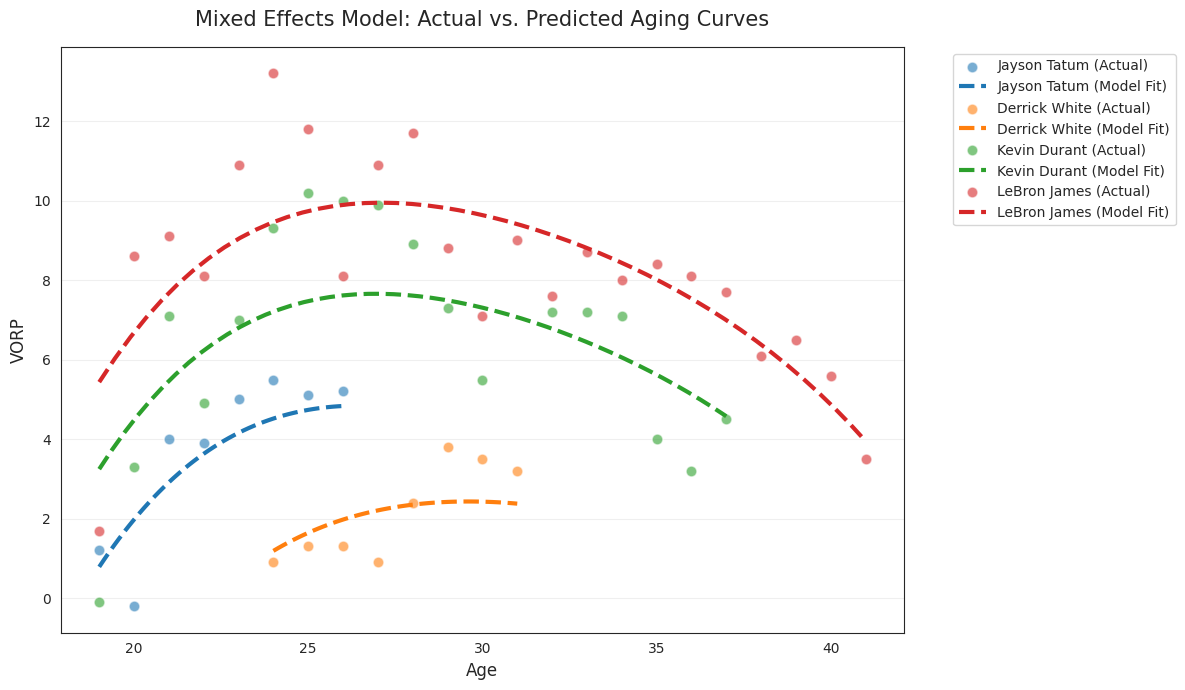

In [29]:
# Get the random effects for every player
random_effects = mdf.random_effects

import seaborn as sns
import matplotlib.pyplot as plt
# Let's pick a few players to compare
players_to_plot = ['Jayson Tatum', 'Derrick White', 'Kevin Durant', 'LeBron James'] 

# 1. Setup the plot
plt.figure(figsize=(12, 7))
sns.set_style("white")

# Define a color palette so the line and dots match for each player
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

for i, player in enumerate(players_to_plot):
    if player in random_effects:
        # --- A. Plot Actual Values (Scatter) ---
        player_data = df_model[df_model['name'] == player]
        plt.scatter(player_data['age'], player_data['BPM'], 
                    color=colors[i], alpha=0.6, s=60, edgecolors='white', label=f"{player} (Actual)")

        # --- B. Get Player-Specific Model Params ---
        re = random_effects[player]
        
        # We only want to plot the curve for the ages they actually played 
        # (or slightly beyond) to avoid wild extrapolations.
        age_min, age_max = player_data['age'].min(), player_data['age'].max()
        ages = np.linspace(age_min, age_max, 50)

        pred = (
            (mdf.params['Intercept'] + re['Group'])
            + (mdf.params['age'] + re['age']) * ages
            + mdf.params['age_sq'] * (ages**2)
            + mdf.params['age_cu'] * (ages**3)
            + mdf.params['age_4'] * (ages**4)
        )
        
        # --- C. Plot Predicted Curve (Line) ---
        plt.plot(ages, pred, color=colors[i], linewidth=3, linestyle='--', 
                 label=f"{player} (Model Fit)")

# 4. Final Formatting
plt.title("Mixed Effects Model: Actual vs. Predicted Aging Curves", fontsize=15, pad=15)
plt.xlabel("Age", fontsize=12)
plt.ylabel("VORP", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside for clarity
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()